# Benchmark Analysis: `simplify_SH` vs DP / DOTS / SQUISH

This notebook analyses the results from `compare_points.csv`, produced by
`benchmark.py`. Each row records the output of one (id, baseline) pair:
- the baseline algorithm (DP / DOTS / SQUISH) was run on the original trajectory,
- then `simplify_SH` was run for ε ∈ {0.25, 0.5, 0.75} with `δ = baseline_frechet / (1+ε)`,
- the row keeps the best (smallest) `simplify_frechet` and its point count.

`baseline_time` and `simplify_time` are wall-clock seconds recorded by
`benchmark.py`. A `-1` in any numeric column indicates the corresponding
step failed (timeout, memcap, or binary error); failed rows are excluded from
the analyses unless explicitly retained for a failure-mode plot.

The headline question: **does `simplify_SH` produce trajectories that are
smaller (fewer points) AND at least as accurate (≤ Frechet distance) as the
baselines?**

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.float_format', lambda x: f'{x:.4g}' if abs(x) > 1e-3 else f'{x:.3e}')

CSV = 'compare_points.csv'
df = pd.read_csv(CSV)
print(f'Loaded {len(df)} rows from {CSV}  (unique IDs: {df["id"].nunique()})')
df.head()

Loaded 300 rows from compare_points.csv  (unique IDs: 100)


,id,baseline_algo,original_points,baseline_points,simplify_points,baseline_frechet,simplify_frechet,baseline_time,simplify_time,best_e,best_d
0,4,DP,672,75,82,217,183.7,0.003977,0.285,0.8,120.6
1,4,DOTS,672,135,108,22.24,18.82,0.01997,0.2262,0.8,12.35
2,4,SQUISH,672,67,48,738.4,624.9,0.004374,0.1775,0.8,410.2
3,1,DP,588,98,66,665.7,563.4,0.004076,0.2615,0.8,369.9
4,1,DOTS,588,194,140,29.77,25.2,0.02296,0.2721,0.8,16.54


## 1. Data overview

Sanity check the schema, then count successes vs failures per baseline.
A "valid" row has no `-1` in any of the four key columns:
`baseline_points`, `simplify_points`, `baseline_frechet`, `simplify_frechet`.

In [25]:
df['valid'] = (
    (df['baseline_points']   != -1) & (df['simplify_points']   != -1) &
    (df['baseline_frechet']  != -1) & (df['simplify_frechet']  != -1)
)

print('Per-baseline success rate:')
(
    df.groupby('baseline_algo')['valid']
      .agg(['count', 'sum', lambda s: f'{s.mean()*100:.1f}%'])
      .rename(columns={'sum': 'valid', '<lambda_0>': 'rate'})
)

Per-baseline success rate:


,count,valid,rate
baseline_algo,,,
DOTS,100,99,99.0%
DP,100,100,100.0%
SQUISH,100,93,93.0%


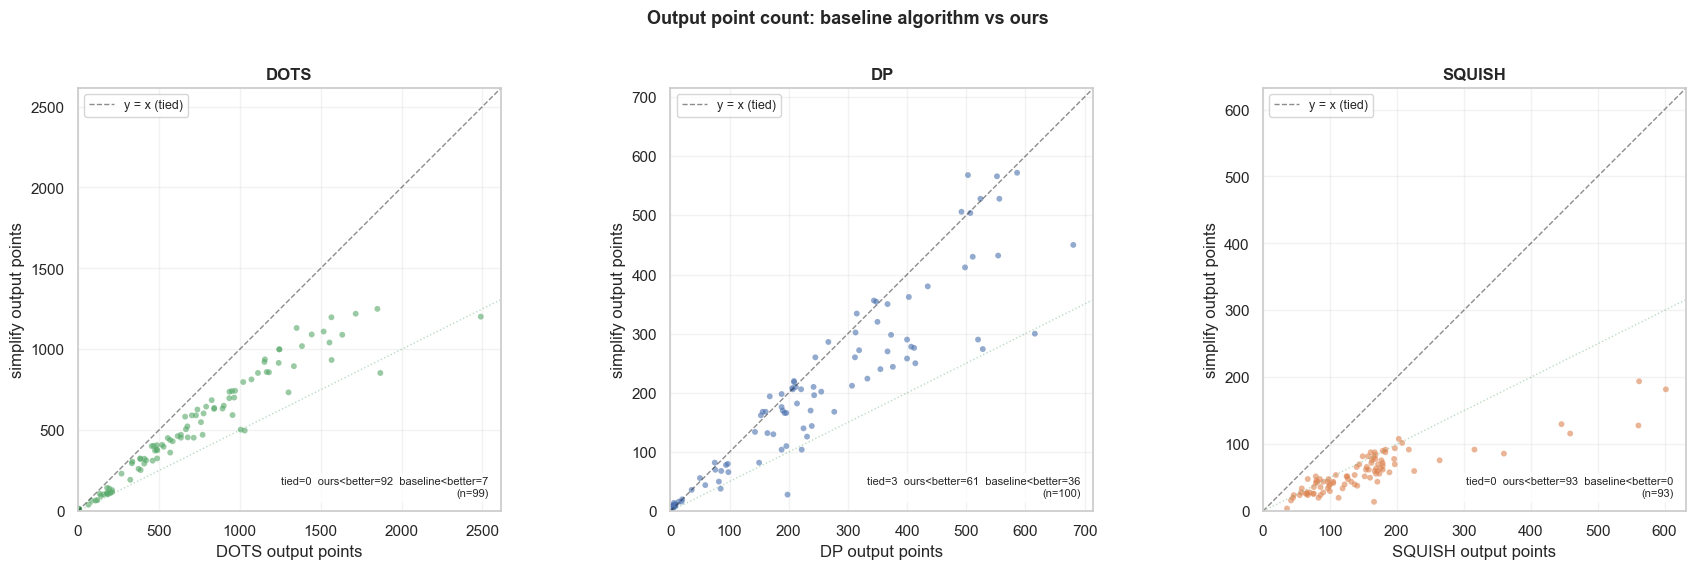

In [26]:
# Number of points: baseline vs ours, one panel per baseline algorithm.
# Points above the y=x line mean `simplify_SH` produced more points
# (worse compression); points below mean it produced fewer (better).
# Points on the line are tied.
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5), sharey=False)

valid = df[df['valid']]
for ax, algo, color in [
    (axes[0], 'DOTS',   'C2'),
    (axes[1], 'DP',     'C0'),
    (axes[2], 'SQUISH', 'C1'),
]:
    sub = valid[valid['baseline_algo'] == algo]
    ax.scatter(sub['baseline_points'], sub['simplify_points'],
               alpha=0.6, s=18, color=color, edgecolors='none')

    # y = x reference line, with a 5% pad on each end so points on the line
    # don't sit on the axis.
    hi = int(max(sub['baseline_points'].max(), sub['simplify_points'].max()) * 1.05)
    lo = 0
    ax.plot([lo, hi], [lo, hi], 'k--', alpha=0.5, linewidth=1, label='y = x (tied)')
    ax.plot([lo, hi], [lo, hi/2], 'g:', alpha=0.4, linewidth=1,)

    ax.set_xlim(lo, hi)
    ax.set_ylim(lo, hi)
    ax.set_aspect('equal', adjustable='box')
    ax.set_title(algo, fontsize=12, fontweight='bold')
    ax.set_xlabel(f'{algo} output points')
    ax.set_ylabel('simplify output points')
    ax.grid(True, alpha=0.25)
    ax.legend(loc='upper left', fontsize=9)

    n_tied   = int(np.sum(sub['simplify_points'] == sub['baseline_points']))
    n_ours   = int(np.sum(sub['simplify_points'] <  sub['baseline_points']))
    n_baseln = int(np.sum(sub['simplify_points'] >  sub['baseline_points']))
    total    = len(sub)
    ax.text(0.97, 0.03,
            f'tied={n_tied}  ours<better={n_ours}  baseline<better={n_baseln}\n(n={total})',
            transform=ax.transAxes, ha='right', va='bottom', fontsize=8,
            bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.7))

plt.suptitle('Output point count: baseline algorithm vs ours',
             y=1.02, fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

/var/folders/f3/h4301l8d7hn_1612_5g5hpmw0000gn/T/ipykernel_50831/3683545426.py:79: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc='upper left', fontsize=9)


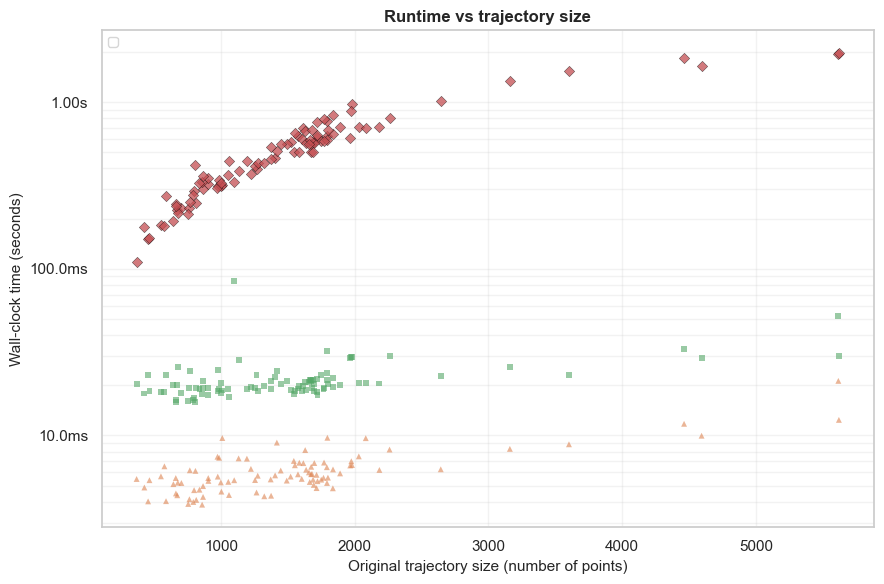

In [27]:
# Runtime vs trajectory size.  DOTS and SQUISH (the online algorithms) and
# our algorithm (`simplify_SH`) are plotted on the same axes for direct
# comparison.  Each baseline gets one timing per (id, baseline_algo)
# row; `simplify_SH` is one timing per id, so we dedupe by id before
# plotting to avoid overplotting.
#
# Y axis is log-scaled so the fast baselines (~1–100 ms) are visible
# alongside simplify_SH (~1–30 s) — a ~100–10,000× gap that would be
# compressed to a flat line on a linear y-axis.  X axis is also log
# because trajectory sizes span three orders of magnitude.

# Restrict to ids where DOTS, SQUISH, and Our (simplify_SH) all have results,
# so every vertical (x) line passes through either 3 points (DOTS, SQUISH,
# Ours) or 0 points.  We pivot on `id` x `baseline_algo` over the valid rows
# and require all three columns to be present.
valid_algos = (
    valid.pivot_table(
        index='id',
        columns='baseline_algo',
        values='baseline_time',
        aggfunc='first',
    )
)
complete_ids = valid_algos.dropna(subset=['DOTS', 'SQUISH']).index
# Also drop ids where simplify_time itself is missing or non-positive.
sh_unique = (
    valid[valid['baseline_algo'].isin(['DOTS', 'SQUISH'])
          & valid['id'].isin(complete_ids)
          & (valid['simplify_time'] > 0)][['id', 'original_points', 'simplify_time']]
    .drop_duplicates('id')
    .rename(columns={'simplify_time': 'time'})
)
sh_unique['algo'] = 'simplify_SH'

# Restrict the per-baseline points to the same complete id set so the
# vertical lines through any plotted x have exactly three points.
dots_sub    = valid[(valid['baseline_algo'] == 'DOTS')   & valid['id'].isin(complete_ids)]
squish_sub  = valid[(valid['baseline_algo'] == 'SQUISH') & valid['id'].isin(complete_ids)]

fig, ax = plt.subplots(figsize=(9, 6))
style = {
    'DOTS':           dict(color='C2', marker='s', label='DOTS (online)'),
    'SQUISH':         dict(color='C1', marker='^', label='SQUISH (online)'),
    'simplify_SH':    dict(color='C3', marker='D', edgecolors='black', linewidths=0.3, s=28,
                           label='simplify (this work)'),
}

for sub, algo in [(dots_sub, 'DOTS'), (squish_sub, 'SQUISH')]:
    kw = dict(alpha=0.6, s=18, edgecolors='none')
    kw.update({k: v for k, v in style[algo].items() if k not in ('label',)})
    ax.scatter(sub['original_points'], sub['baseline_time'], **kw)

kw = dict(alpha=0.75)
kw.update({k: v for k, v in style['simplify_SH'].items() if k != 'label'})
ax.scatter(sh_unique['original_points'], sh_unique['time'], **kw)

ax.set_xscale('linear')
ax.set_yscale('log')
def format_time(x, pos):
    if x < 0.001:
        return f'{x*1000:.0f}ms'
    elif x < 1:
        return f'{x*1000:.1f}ms'
    elif x < 10:
        return f'{x:.2f}s'
    else:
        return f'{x:.1f}s'

ax.yaxis.set_major_formatter(plt.FuncFormatter(format_time))
ax.set_xlabel('Original trajectory size (number of points)', fontsize=11)
ax.set_ylabel('Wall-clock time (seconds)', fontsize=11)
ax.set_title('Runtime vs trajectory size', fontsize=12, fontweight='bold')
ax.grid(True, which='both', alpha=0.25)

# Annotated speedup annotation line
median_sh  = sh_unique['time'].median()
median_d   = dots_sub['baseline_time'].median()
median_sq  = squish_sub['baseline_time'].median()
ax.legend(loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()

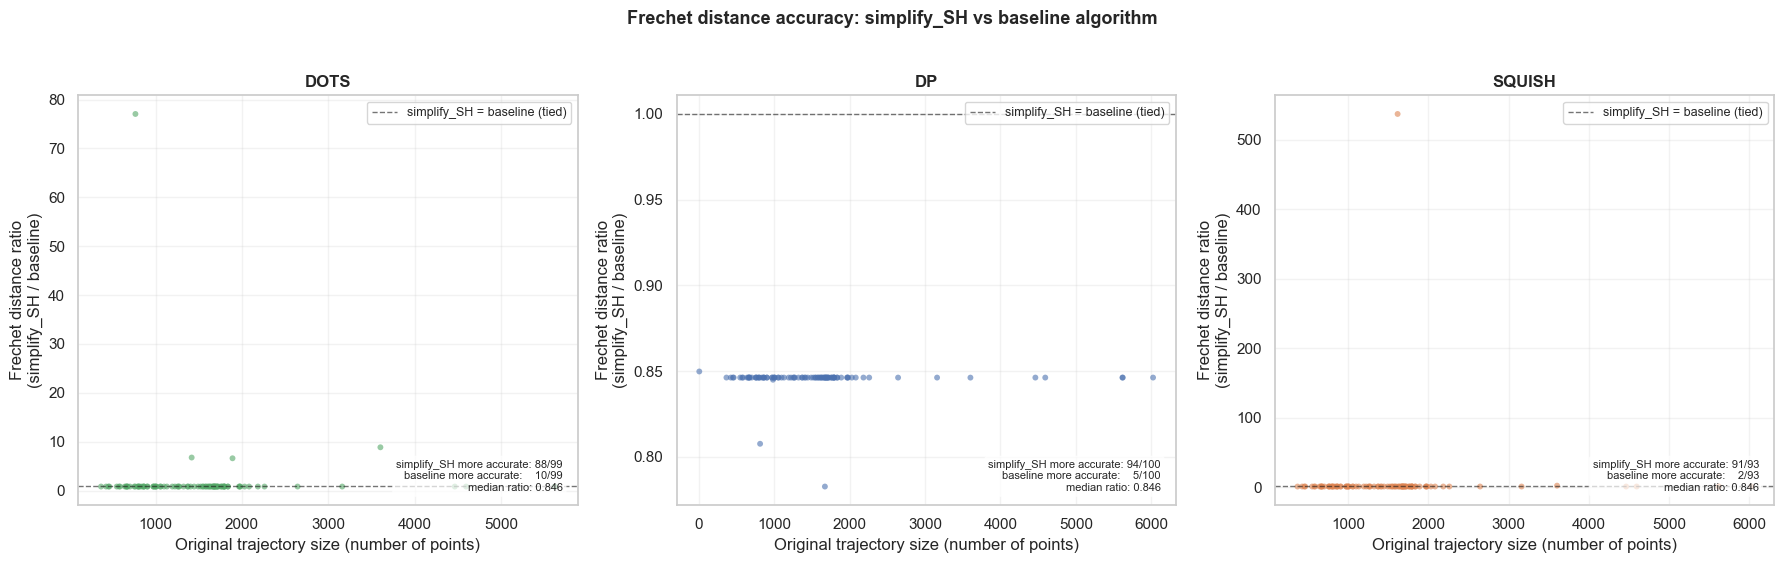

In [28]:
# Frechet distance accuracy: baseline vs simplify_SH.
# y = simplify_frechet / baseline_frechet  →  < 1 means simplify_SH
# is more accurate (smaller Frechet distance) than the baseline.
# Both axes are linear scale.

valid = valid.copy()
valid.loc[:, 'frechet_ratio'] = valid['simplify_frechet'] / valid['baseline_frechet']

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
for ax, algo, color in [
    (axes[0], 'DOTS',   'C2'),
    (axes[1], 'DP',     'C0'),
    (axes[2], 'SQUISH', 'C1'),
]:
    sub = valid[valid['baseline_algo'] == algo]
    ax.scatter(sub['original_points'], sub['frechet_ratio'],
               alpha=0.6, s=18, color=color, edgecolors='none')

    ax.axhline(1.0, color='k', linestyle='--', alpha=0.6, linewidth=1,
               label='simplify_SH = baseline (tied)')
    ax.set_title(algo, fontsize=12, fontweight='bold')
    ax.set_xlabel('Original trajectory size (number of points)')
    ax.set_ylabel('Frechet distance ratio\n(simplify_SH / baseline)')
    ax.grid(True, alpha=0.25)
    ax.legend(loc='upper right', fontsize=9)

    below = int(np.sum(sub['frechet_ratio'] < 1.0))
    above = int(np.sum(sub['frechet_ratio'] > 1.0))
    total = len(sub)
    med_ratio = sub['frechet_ratio'].median()
    ax.text(0.97, 0.03,
            f'simplify_SH more accurate: {below}/{total}\n'
            f'baseline more accurate:    {above}/{total}\n'
            f'median ratio: {med_ratio:.3f}',
            transform=ax.transAxes, ha='right', va='bottom', fontsize=8,
            bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.7))

plt.suptitle('Frechet distance accuracy: simplify_SH vs baseline algorithm',
             y=1.02, fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()